# Session 3, Block 2 &mdash; Causality
**Data Science Techniques and Real-World Applications &mdash; WS 2026**

**Zahra Sharafi**

**Frankfurt School of Finance and Management**

Thursday 17 September 2026 

We found that GOOG's return is a statistically significant predictor of AAPL's return.
Before you act on a finding like that, one question matters more than the p-value: **does it mean
anything is causing anything?**

This block is about the difference between a coefficient and a cause &mdash; and what you can
actually do about it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.formula.api as smf

df = pd.read_excel("data/techstocks.xlsx", sheet_name="main")
df = df.rename(columns={"Return on the S&P 500 Index": "MktReturn"})
wide = df.pivot(
    index="Names Date",        # each unique date becomes one row
    columns="Ticker Symbol",   # each unique ticker becomes its own column
    values="Returns",          # cells filled with that (date, ticker)'s Returns
)
wide["MktReturn"] = df.groupby("Names Date")["MktReturn"].mean()
wide = wide.dropna()
wide.head()

Ticker Symbol,AAPL,AMZN,GOOG,NFLX,MktReturn
Names Date,,,,,
2018-01-02,0.017905,0.016708,0.017775,0.047458,0.008303
2018-01-03,-0.000174,0.012775,0.016413,0.019794,0.006399
2018-01-04,0.004645,0.004476,0.003621,0.002829,0.004029
2018-01-05,0.011385,0.016163,0.014571,0.021203,0.007034
2018-01-08,-0.003714,0.014425,0.004273,0.009810,0.001662


## <span style="color:#1e3a8a">Correlation vs. causation</span>

Two classic warm-up examples:
- Ice cream sales and drowning deaths rise and fall together, month by month. Ice cream doesn't
  cause drowning &mdash; **hot weather** drives both: more swimming, more ice cream.
- Regions where storks nest more often also have more human births. Storks don't deliver babies
  &mdash; both are higher in **more rural areas**, which happens to have both more stork habitat and
  higher birth rates.

Our own regression from last block fits the same pattern. GOOG's return "explains" AAPL's return
&mdash; not because trading GOOG moves AAPL's price, but because a third factor drives both: **the
overall market**. We'll come back to this exact example with real numbers below.

**The general shape of the mistake:** $X$ and $Y$ move together because a third variable $Z$ affects
both, not because $X$ affects $Y$. $Z$ here is called a **confounder**.

## <span style="color:#1e3a8a">A framework for causal thinking</span>

- **Intervention (treatment)**: a decision or action that changes something &mdash; e.g. a company
  changes its price, a policy changes a tax rate, an app shows a new ad design.
- **Subjects**: whoever or whatever could be affected by the intervention &mdash; customers, firms,
  users, days.
- **Outcome ($y$)**: the variable we think the intervention might affect.
- **Causal variable ($x$)**: the variable indicating the intervention &mdash; often binary
  (treated / not treated), sometimes a matter of degree.

### Potential outcomes

For each subject $i$, imagine two possible worlds:
- $y_i^1$: the outcome *if* subject $i$ is treated.
- $y_i^0$: the outcome *if* subject $i$ is not treated.

The **individual treatment effect** is $TE_i = y_i^1 - y_i^0$.

**The fundamental problem:** for any given subject, we only ever observe *one* of these two
outcomes &mdash; whichever one actually happened. The other is a **counterfactual**: what would have
happened, had things gone differently. We can never directly measure an individual treatment
effect. Everything in causal analysis is about approximating it anyway, using groups of subjects.

### The average treatment effect (ATE)

Since we can't see individual effects, we target their average across subjects instead:

$$ATE = E[y^1] - E[y^0]$$

the average outcome *if everyone were treated*, minus the average outcome *if no one were treated*.
Still built from potential outcomes we can't fully observe &mdash; but it turns out we can
*estimate* it under the right conditions.

## <span style="color:#1e3a8a">Estimating the ATE: simple difference in means</span>

The most natural estimator compares the subjects who happened to be treated against the ones who
weren't:

$$SDO = \overline{y}_{\text{treated}} - \overline{y}_{\text{untreated}}$$

(SDO: "simple difference in outcomes.") **This equals the ATE only if treatment assignment is
independent of the potential outcomes** &mdash; i.e., whether a subject ended up treated has nothing
to do with how they'd have responded either way. This holds automatically under **random
assignment** (a controlled experiment, or a natural experiment). It does *not* hold when treatment
is correlated with something that also affects the outcome &mdash; that's **selection bias**.

Let's make this concrete with a simulation, where &mdash; because we're generating the data
ourselves &mdash; we know the *true* ATE and can check whether SDO recovers it.

### A simulated marketing example

4,000 customers, each with a `loyalty` score. Loyalty drives baseline spending regardless of any
marketing email. The **true effect of the email is fixed at +30** (we're building the data, so we
get to know this for certain). We compare two ways the email could have been sent out.

In [2]:
rng = np.random.default_rng(42)
n = 4000
loyalty = rng.normal(50, 15, n)
true_ate = 30.0
noise = rng.normal(0, 20, n)
base_spending = 100 + 2 * loyalty + noise  # baseline spending, driven by loyalty

**Scenario A &mdash; confounded assignment.** Marketing sends the email mainly to already-loyal
customers (a common, well-intentioned targeting choice).

In [3]:
p_treat_confounded = 1 / (1 + np.exp(-(loyalty - 50) / 8))
treated_confounded = rng.random(n) < p_treat_confounded
spending_confounded = base_spending + treated_confounded * true_ate

sdo_confounded = spending_confounded[treated_confounded].mean() - spending_confounded[~treated_confounded].mean()
print(f"share who received the email: {treated_confounded.mean():.2f}")
print(f"SDO (confounded assignment):  {sdo_confounded:.2f}   |   true ATE: {true_ate:.0f}")

share who received the email: 0.49
SDO (confounded assignment):  65.78   |   true ATE: 30


**Scenario B &mdash; random assignment.** Same customers, same true effect, but now the email is a
coin flip, unrelated to loyalty.

In [4]:
treated_random = rng.random(n) < 0.5
spending_random = base_spending + treated_random * true_ate
sdo_random = spending_random[treated_random].mean() - spending_random[~treated_random].mean()
print(f"SDO (random assignment):      {sdo_random:.2f}   |   true ATE: {true_ate:.0f}")

SDO (random assignment):      31.66   |   true ATE: 30


Under confounded assignment, SDO overstates the true effect by more than double &mdash; not because
the email doesn't work, but because loyal customers would have spent more *anyway*. Under random
assignment, SDO lands close to the true 30. **The data-generating process was identical except for
how treatment was assigned** &mdash; assignment, not the outcome variable, is what made the estimate
honest.

This is why randomized experiments (A/B tests) are the gold standard for causal claims: they make
the independence assumption true by construction, instead of hoping it holds.

## <span style="color:#1e3a8a">Confounders and causal maps</span>

A **confounder** is a variable that affects both the causal variable $x$ and the outcome $y$. A
**causal map** (or **directed acyclic graph**, DAG) is a simple diagram of your assumptions about
which variables affect which &mdash; arrows point from cause to effect.

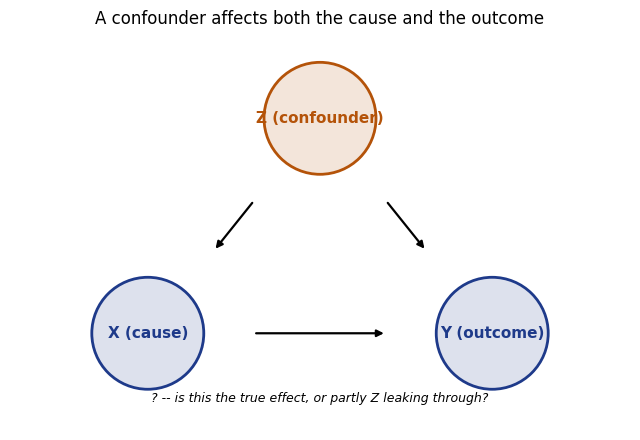

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
pos = {"Z (confounder)": (0.5, 1.0), "X (cause)": (0.0, 0.0), "Y (outcome)": (1.0, 0.0)}
for label, (px, py) in pos.items():
    color = "#b45309" if "Z" in label else "#1e3a8a"
    ax.scatter([px], [py], s=6500, color=color, alpha=0.15, zorder=1)
    ax.scatter([px], [py], s=6500, facecolors="none", edgecolors=color, linewidths=2, zorder=2)
    ax.annotate(label, (px, py), ha="center", va="center", fontsize=11, fontweight="bold", color=color, zorder=3)

def arrow(p_from, p_to, style="-|>"):
    ax.annotate(
        "", xy=p_to, xytext=p_from,
        arrowprops=dict(arrowstyle=style, color="black", lw=1.6,
                         shrinkA=78, shrinkB=78, connectionstyle="arc3,rad=0.0"),
    )

arrow(pos["Z (confounder)"], pos["X (cause)"])
arrow(pos["Z (confounder)"], pos["Y (outcome)"])
arrow(pos["X (cause)"], pos["Y (outcome)"])
ax.text(0.5, -0.32, "? -- is this the true effect, or partly Z leaking through?", ha="center", fontsize=9, style="italic")

ax.set_xlim(-0.4, 1.4)
ax.set_ylim(-0.45, 1.4)
ax.axis("off")
ax.set_title("A confounder affects both the cause and the outcome")
plt.tight_layout()
plt.show()

**A real example (Bekes & Kezdi, our course textbook):** does eating more fruit and vegetables
lower blood pressure? A naive comparison confounds several things at once:
- **Socio-economic status** affects both diet and overall health, including blood pressure.
- **Reverse causality**: people already advised about high blood pressure may eat healthier *because*
  of that advice &mdash; the arrow may run the other way.
- **Health consciousness** affects diet and a whole range of health outcomes at once.

None of these show up if you just compute a correlation. They only surface once you draw the map
and ask: what else could be driving both variables?

## <span style="color:#1e3a8a">Omitted variable bias, made concrete</span>

Back to AAPL and GOOG. Regress AAPL's return on GOOG's return **alone** &mdash; no market control:

In [6]:
model_naive = smf.ols("AAPL ~ GOOG", data=wide).fit()
print(model_naive.params)
print(model_naive.pvalues)

Intercept    0.001119
GOOG         0.792623
dtype: float64
Intercept     5.364272e-02
GOOG         3.936489e-110
dtype: float64


Now add `MktReturn` &mdash; the confounder driving both stocks &mdash; as a control:

In [7]:
model_controlled = smf.ols("AAPL ~ GOOG + MktReturn", data=wide).fit()
print(model_controlled.params)
print(model_controlled.pvalues)

Intercept    0.001089
GOOG         0.197538
MktReturn    0.981570
dtype: float64
Intercept    2.529953e-02
GOOG         2.593938e-06
MktReturn    1.084991e-59
dtype: float64


In [8]:
print(f"GOOG coefficient, no control:      {model_naive.params['GOOG']:.3f}")
print(f"GOOG coefficient, market controlled: {model_controlled.params['GOOG']:.3f}")
print(f"correlation(GOOG, MktReturn):        {wide['GOOG'].corr(wide['MktReturn']):.3f}")

GOOG coefficient, no control:      0.793
GOOG coefficient, market controlled: 0.198
correlation(GOOG, MktReturn):        0.799


The `GOOG` coefficient drops from about 0.79 to about 0.20 once we control for the market &mdash;
it shrinks to roughly a quarter of its original size. The 0.79 was never really "the effect of GOOG
on AAPL"; it was mostly GOOG's return standing in for the market move that both stocks share
(the two are correlated at about 0.80). **This is omitted variable bias**: leaving a confounder out
of the regression lets its effect leak into the coefficient of whatever variable you did include.

Omitted variable bias runs in a predictable direction: the more strongly a left-out confounder is
correlated with both $x$ and $y$, the more the coefficient on $x$ is distorted. There's still a
significant, real association between AAPL and GOOG even after controlling for the market (plausibly
shared tech-sector news) &mdash; the point isn't that the controlled number is "the truth," but that
it's far more honest than the naive one, and there may still be confounders we haven't thought of.

## <span style="color:#1e3a8a">Bad controls: more variables isn't always better</span>

Controlling for confounders helps. But controlling for the *wrong* variable can hurt. A classic
trap: controlling for a variable that is itself a **consequence** of the causal variable, not a
cause of it.

Example: to study whether manager training improves team productivity, you might be tempted to
control for employee satisfaction. But if training *causes* higher satisfaction, which in turn
raises productivity, controlling for satisfaction blocks off part of the very effect you're trying
to measure &mdash; the estimated "effect of training" will look artificially small or even zero.

The rule of thumb: only control for variables you're confident come *before* and *independently of*
the causal variable, not ones that could themselves be shaped by it.

## <span style="color:#1e3a8a">Experiments vs. conditioning</span>

Two broad strategies for getting closer to a causal claim:

1. **Experiment**: randomly assign the causal variable yourself (an A/B test). This guarantees
   independence from any confounder, observed or not &mdash; by construction, exactly as in our
   marketing simulation above. Often the gold standard, but frequently impractical, unethical, or
   simply impossible (you can't randomly assign a company's revenue, or a country's interest rate).
2. **Conditioning on observational data**: control for the confounders you can measure &mdash; e.g.
   including `MktReturn` in the regression above. This is sometimes called a *ceteris paribus*
   ("all else equal") analysis. Its weakness: it only protects you against confounders you actually
   thought to include. Any confounder you didn't measure, or didn't think of, still biases the
   result.

<span style="color:#b45309">**Exercise: Find the confounder**</span>

Test whether NFLX's `Returns` predict AMZN's `Returns`, both without and with a `MktReturn`
control (same pattern as the AAPL/GOOG example above). Report both coefficients on `NFLX`, and
in a sentence, explain what's driving the shrinkage. 

Then, in 2-3 sentences: propose one real, non-market confounder that could still be missing from
the controlled regression &mdash; something that might affect both stocks' returns beyond overall
market movement.

In [9]:
model_naive = smf.ols("AMZN ~ NFLX", data=wide).fit()
model_controlled = smf.ols("AMZN ~ NFLX + MktReturn", data=wide).fit()

print(f"NFLX coefficient, no control:       {model_naive.params['NFLX']:.3f}  (p={model_naive.pvalues['NFLX']:.2g})")
print(f"NFLX coefficient, market controlled: {model_controlled.params['NFLX']:.3f}  (p={model_controlled.pvalues['NFLX']:.2g})")
print(f"correlation(NFLX, MktReturn):        {wide['NFLX'].corr(wide['MktReturn']):.3f}")

NFLX coefficient, no control:       0.521  (p=1.2e-99)
NFLX coefficient, market controlled: 0.361  (p=2.7e-53)
correlation(NFLX, MktReturn):        0.512


**Explanation:** the NFLX coefficient drops from about 0.52 to about 0.36 once `MktReturn` is added
&mdash; roughly a 30% shrinkage. NFLX and MktReturn are correlated at about 0.51, so part of what
looked like "NFLX explaining AMZN" in the naive regression was really both stocks responding to the
same overall market moves. It's a smaller shrinkage than the AAPL/GOOG example because NFLX is less
tightly tied to the broad market (lower correlation with `MktReturn`) than GOOG was, so there's less
of the confounder's effect to leak into the naive coefficient. Even after controlling for the
market, a real and significant association remains.

**A remaining confounder:** shared sector-specific news is a good candidate &mdash; e.g. a
broad *tech-sector* sentiment shift (regulatory news, interest-rate expectations affecting growth
stocks specifically) that moves AMZN and NFLX together but isn't fully captured by the S&P 500
as a whole, since the S&P 500 also includes non-tech sectors that wouldn't react the same way.

## <span style="color:#1e3a8a">Constructive skepticism: a checklist</span>

> "I would rather discover one cause than be the King of Persia." &mdash; Democritus

Causal language carries weight &mdash; "X causes Y" implies you should act on X to change Y. Before
accepting a causal claim (yours or someone else's), ask:

1. **Is there a plausible confounder** that could drive both variables at once?
2. **Was there random assignment**, or a natural experiment, or are we relying entirely on
   conditioning?
3. **Could reverse causality** explain the pattern just as well as the claimed direction?
4. **Are the controls appropriate** &mdash; confounders that came first, not consequences of the
   causal variable?
5. **Is this the only test that was run**, or one significant result among many that weren't
   reported? (The multiple-testing caution from last block applies here too.)

Every study is imperfect. Some get closer to a clean causal claim than others, but rarely does a
single study settle a question for good &mdash; which is exactly why "be responsible and sound" is
the throughline of this course, not just a Session 3 topic.